In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize, dual_annealing

### Data Acquisition & EDA

In [ ]:
df2_path = '/content/drive/My Drive/measles_full.csv'

In [ ]:
df2 = pd.read_csv(df2_path)
display(df2.head())

,date,Lam.Dong.00.04,Ho.Chi.Minh.City.00.04,Binh.Phuoc.00.04,Tay.Ninh.00.04,Binh.Duong.00.04,Dong.Nai.00.04,Ba.Ria.Vung.Tau.00.04,Long.An.00.04,Dong.Thap.00.04,...,Tien.Giang.25.,Vinh.Long.25.,Ben.Tre.25.,Kien.Giang.25.,Can.Tho.City.25.,Hau.Giang.25.,Tra.Vinh.25.,Soc.Trang.25.,Bac.Lieu.25.,Ca.Mau.25.
0,2018-01-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2018-01-02,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2018-01-03,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2018-01-04,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2018-01-05,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
hcmc_columns = [col for col in df2.columns if 'Ho.Chi.Minh.City' in col]
hcmc_measles_all_ages = df2[['date'] + hcmc_columns]
hcmc_measles_all_ages['date'] = pd.to_datetime(hcmc_measles_all_ages['date'])
hcmc_measles_all_ages['total_cases'] = hcmc_measles_all_ages[hcmc_columns].sum(axis=1)
hcmc_measles_all_ages = hcmc_measles_all_ages[['date', 'total_cases']].sort_values('date')

display(hcmc_measles_all_ages.head())

/tmp/ipython-input-2146368218.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcmc_measles_all_ages['date'] = pd.to_datetime(hcmc_measles_all_ages['date'])
/tmp/ipython-input-2146368218.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hcmc_measles_all_ages['total_cases'] = hcmc_measles_all_ages[hcmc_columns].sum(axis=1)


,date,total_cases
0,2018-01-01,0
1,2018-01-02,1
2,2018-01-03,1
3,2018-01-04,4
4,2018-01-05,0


dữ liệu bệnh sởi tại TP.HCM từ 01/08/2018 đến 31/08/2019

In [ ]:
start_date = '2018-08-01'
end_date = '2019-08-31'
df = hcmc_measles_all_ages[
    (hcmc_measles_all_ages['date'] >= start_date) &
    (hcmc_measles_all_ages['date'] <= end_date)
].copy()
display(df.head())
display(df.tail())

,date,total_cases
212,2018-08-01,0
213,2018-08-02,0
214,2018-08-03,0
215,2018-08-04,0
216,2018-08-05,0


,date,total_cases
603,2019-08-27,7
604,2019-08-28,3
605,2019-08-29,3
606,2019-08-30,2
607,2019-08-31,5


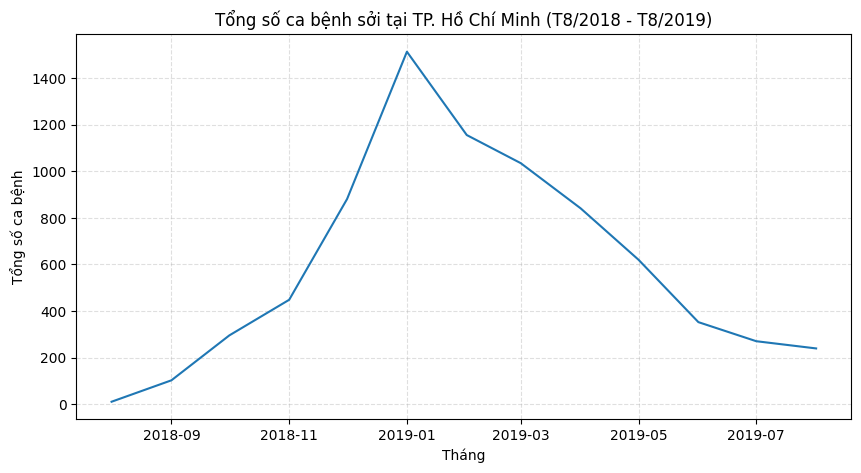

In [ ]:
# tổng hợp dữ liệu theo tháng
monthly_cases = (
    df.set_index('date')['total_cases']
    .resample('MS').sum()   # 'MS' = Month Start
)
# vẽ biểu đồ dạng đường
plt.figure(figsize=(10,5))
plt.plot(monthly_cases.index, monthly_cases.values, color='tab:blue')
plt.title('Tổng số ca bệnh sởi tại TP. Hồ Chí Minh (T8/2018 - T8/2019)')
plt.xlabel('Tháng')
plt.ylabel('Tổng số ca bệnh')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
print(monthly_cases.index)
print(len(monthly_cases))

DatetimeIndex(['2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01',
               '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01',
               '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01',
               '2019-08-01'],
              dtype='datetime64[ns]', name='date', freq='MS')
13


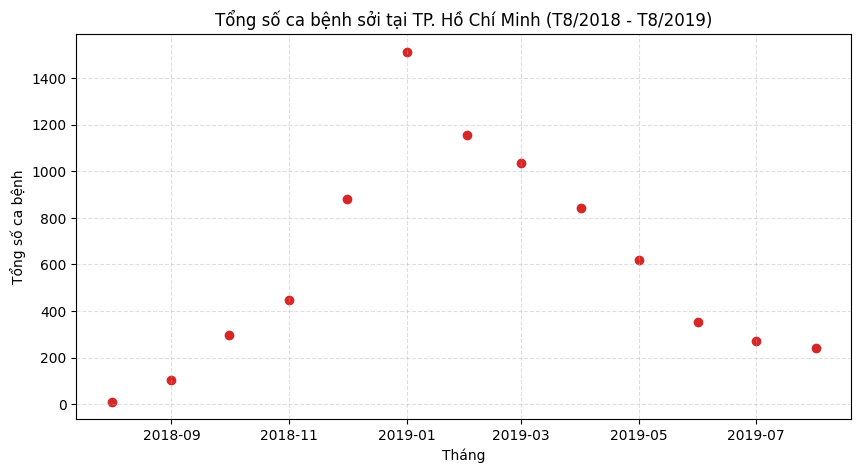

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(monthly_cases.index, monthly_cases.values, color='tab:red')
plt.title('Tổng số ca bệnh sởi tại TP. Hồ Chí Minh (T8/2018 - T8/2019)')
plt.xlabel('Tháng')
plt.ylabel('Tổng số ca bệnh')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

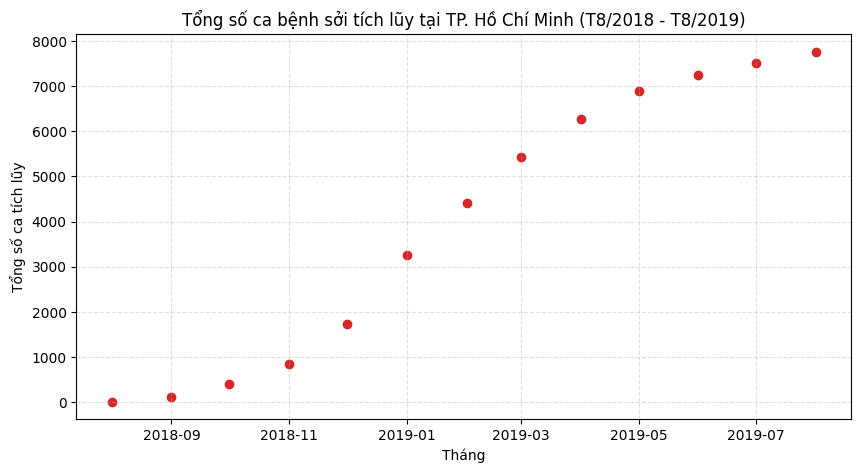

In [ ]:
cumulative_cases = monthly_cases.cumsum()

plt.figure(figsize=(10,5))
plt.scatter(cumulative_cases.index, cumulative_cases.values, color='tab:red')
plt.title('Tổng số ca bệnh sởi tích lũy tại TP. Hồ Chí Minh (T8/2018 - T8/2019)')
plt.xlabel('Tháng')
plt.ylabel('Tổng số ca tích lũy')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### Model SEIR

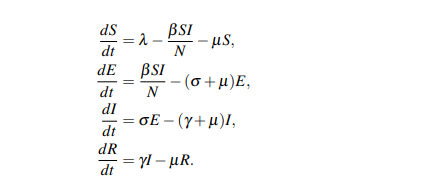

- Lamda: tốc độ sinh, bổ sung nhóm người vào ngăn S
- mu: tỷ lệ tử vong tự nhiên = tỷ lệ sinh tự nhiên
- beta: tốc độ lây truyền
- sigma: tốc độ chuyển từ E sang I = 1/incubation (1/ thời gian ủ bệnh)
- gamma: tốc độ hồi phục = 1/ thời gian lây nhiễm

In [ ]:
july_2018_cases = hcmc_measles_all_ages[
    (hcmc_measles_all_ages['date'].dt.year == 2018) &
    (hcmc_measles_all_ages['date'].dt.month == 7)
]

# tính tổng số ca trong tháng 7 năm 2018
total_cases_july_2018 = july_2018_cases['total_cases'].sum()

print(f"Tổng số ca mắc sởi tại TP. Hồ Chí Minh trong tháng 7 năm 2018 là: {total_cases_july_2018}")

Tổng số ca mắc sởi tại TP. Hồ Chí Minh trong tháng 7 năm 2018 là: 3


#### fitting

In [ ]:
t_data = np.arange(len(monthly_cases))        # t = 0..T-1 (tháng)
y_data = monthly_cases.values.astype(float)

# tham số và đk ban đầu
N = 8843200 # https://maisonoffice.vn/tin-tuc/dan-so-tphcm/
mu = (1/75) / 12 # https://baochinhphu.vn/tuoi-tho-trung-binh-cua-nguoi-viet-nam-dat-745-tuoi-102240711142540252.htm
sigma = 1/ (10/30) # https://www.vinmec.com/vie/bai-viet/thoi-gian-u-benh-soi-la-bao-lau-vi
gamma = 1/ (7/30) # assumed
Lambda = mu * N # N = constant <- assumed from model

I0 = 10
E0 = 2 * I0
R0 = 0
S0 = N - (E0 + I0 + R0)
y0 = [S0, E0, I0, R0]

def beta_t(t, beta0, a_beta, phi):
    """β(t) = β₀ (1 + aβ sin(2πt/12 + φ))"""
    return beta0 * (1 + a_beta * np.sin(2 * np.pi * t / 12 + phi))

def seir_ode(y, t, params):
    S, E, I, R = y
    beta0, a_beta, phi = params
    beta = beta_t(t, beta0, a_beta, phi)
    dS = Lambda - beta*S*I/N - mu*S
    dE = beta*S*I/N - (sigma + mu)*E
    dI = sigma*E - (gamma + mu)*I
    dR = gamma*I - mu*R
    return [dS, dE, dI, dR]

def simulate(params, t_range):
    sol = odeint(seir_ode, y0, t_range, args=(params,))
    S, E, I, R = sol.T
    incidence = sigma * E                     # số ca phát bệnh mỗi tháng
    return np.clip(incidence, 0, None)

def objective(params):
    pred = simulate(params, t_data)
    pred = np.clip(pred, 1e-9, None)
    scale = np.mean(y_data) / np.mean(pred)    # scale
    y_pred = pred * scale
    ss_res = np.sum((y_data - y_pred)**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    R2 = 1 - ss_res / ss_tot
    return 1 - R2                              # minimize(1 - R²)

bounds = [
    (10, 40),      # beta_0 (để R_0 > 1 phản ảnh outbreak của bệnh sởi)
    (0.1, 0.9),    # a_beta, giới hạn để đảm bảo beta(t) > 0
    (-np.pi, np.pi) # phi, giới hạn trong một chu kỳ đầy đủ
]

print("Global optimization (Dual Annealing)")
res_g = dual_annealing(
    objective,
    bounds=bounds,
    maxiter=2000,      # tăng số vòng lặp
    seed=42,           # cố định random seed để tái lập
    no_local_search=True  # local search
)
print(f"Global best (1 - R²): {res_g.fun:.6f}")

print("\nLocal refinement (L-BFGS-B)")
res = minimize(
    objective,
    res_g.x,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 5000, 'ftol': 1e-10, 'gtol': 1e-8}
)
print(f"Final (1 - R²): {res.fun:.6f}  →  R² = {1 - res.fun:.6f}")
beta0, a_beta, phi = res.x
print(f"Fitted parameters: β₀={beta0:.3f},  aβ={a_beta:.3f},  φ={phi:.3f}")

Global optimization (Dual Annealing)
Global best (1 - R²): 0.075800

Local refinement (L-BFGS-B)
Final (1 - R²): 0.075591  →  R² = 0.924409
Fitted parameters: β₀=12.188,  aβ=0.480,  φ=1.992


#### plot res

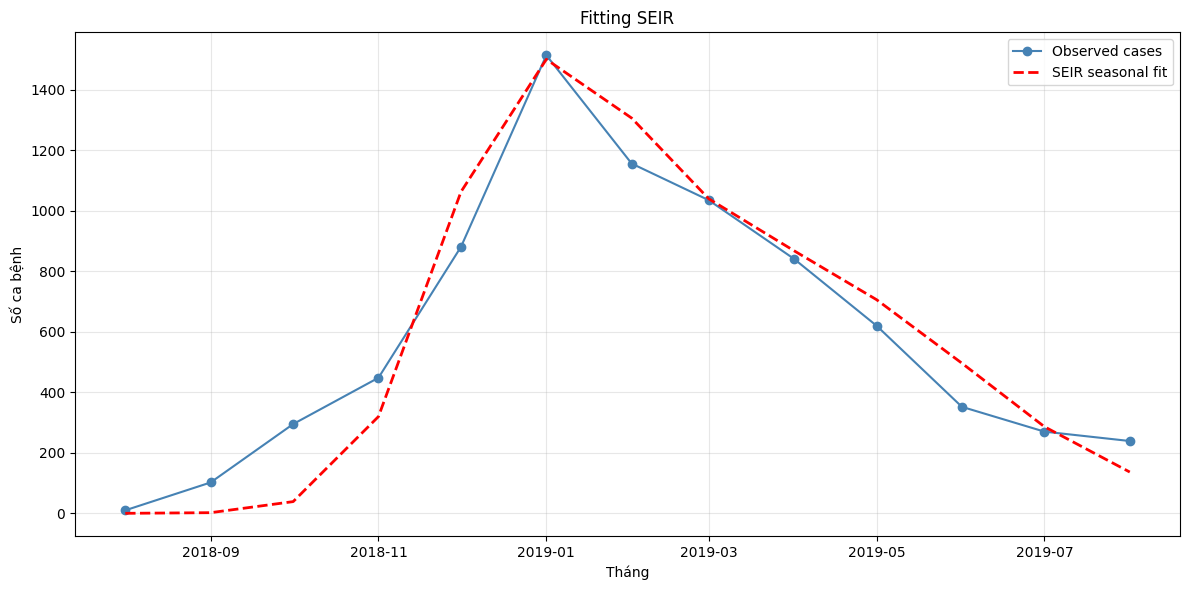

In [ ]:
pred = simulate(res.x, t_data)
scale = np.mean(y_data) / np.mean(pred)
y_pred = pred * scale

plt.figure(figsize=(12,6))
plt.plot(monthly_cases.index, y_data, 'o-', color='steelblue', label='Observed cases')
plt.plot(monthly_cases.index, y_pred, 'r--', lw=2, label='SEIR seasonal fit')
plt.title('Fitting SEIR')
plt.xlabel('Tháng')
plt.ylabel('Số ca bệnh')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

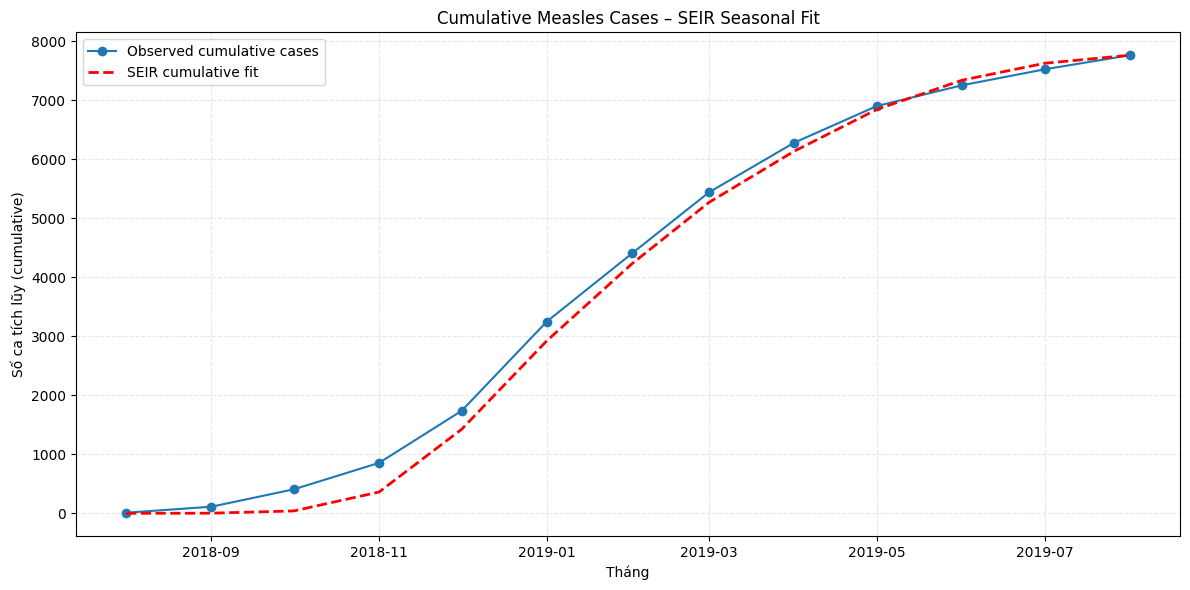

In [ ]:
obs_cum = np.cumsum(y_data)
pred_cum = np.cumsum(y_pred)

plt.figure(figsize=(12,6))
plt.plot(monthly_cases.index, obs_cum, 'o-', color='tab:blue', label='Observed cumulative cases')
plt.plot(monthly_cases.index, pred_cum, 'r--', lw=2, label='SEIR cumulative fit')
plt.title('Cumulative Measles Cases – SEIR Seasonal Fit')
plt.xlabel('Tháng')
plt.ylabel('Số ca tích lũy (cumulative)')
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### R_0 & R_e(t)

In [ ]:
beta0, a_beta, phi = res.x

R0 = (beta0 * sigma) / ((sigma + mu) * (gamma + mu))
print(f"\nEstimated R0 = {R0:.3f}")


Estimated R0 = 2.842


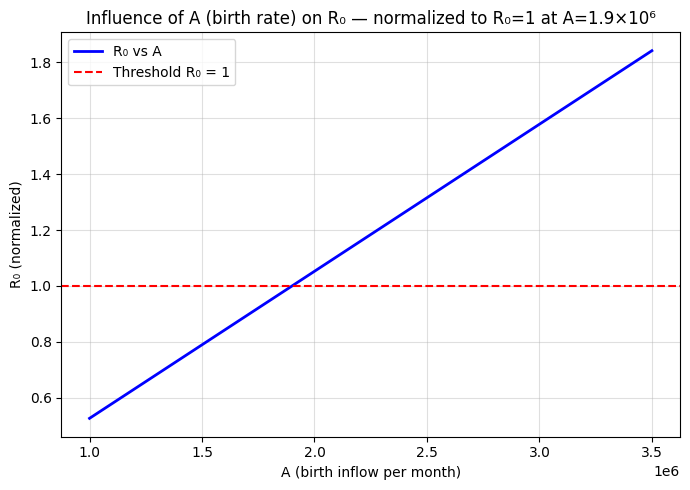

In [ ]:
beta0 = 25.0

# công thức R0 cơ bản
R0_base = (beta0 * sigma) / ((sigma + mu)*(gamma + mu))

# dải A muốn khảo sát
A_vals = np.linspace(1.0e6, 3.5e6, 100)

# giá trị A tham chiếu (A_ref = 1.9×10^6) — tại đây R0 = 1
A_ref = 1.9e6
scale = 1 / (R0_base * (A_ref / 1.3e6))   # hệ số chuẩn hóa để R0(A_ref)=1

# tính R0 cho các giá trị A
R0_vals = R0_base * (A_vals / 1.3e6) * scale

plt.figure(figsize=(7,5))
plt.plot(A_vals, R0_vals, 'b-', lw=2, label='R₀ vs A')
plt.axhline(1, color='r', linestyle='--', lw=1.5, label='Threshold R₀ = 1')
plt.xlabel('A (birth inflow per month)')
plt.ylabel('R₀ (normalized)')
plt.title('Influence of A (birth rate) on R₀ — normalized to R₀=1 at A=1.9×10⁶')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

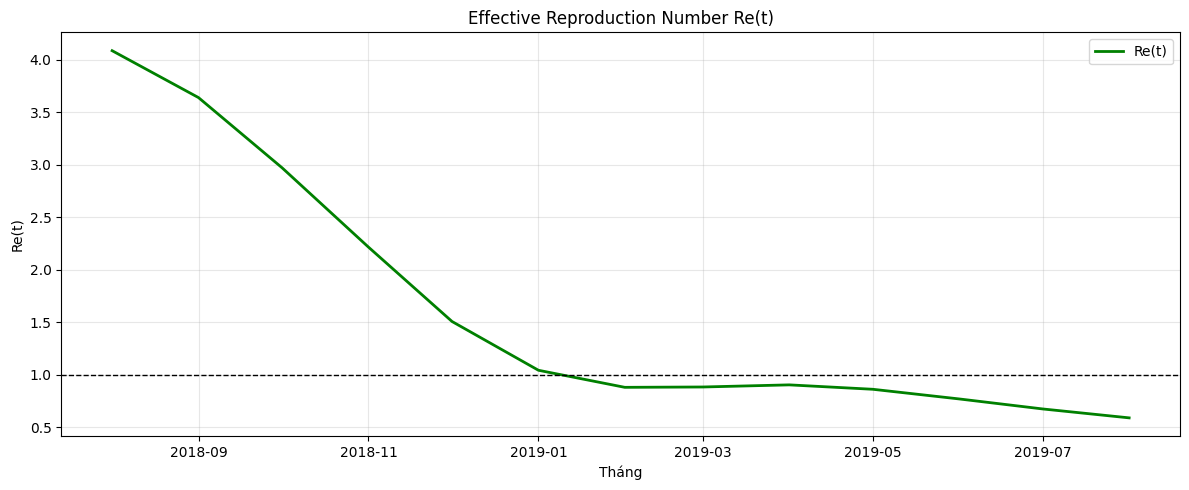

In [ ]:
def simulate(params, t_range):
    sol = odeint(seir_ode, y0, t_range, args=(params,))
    S, E, I, R = sol.T

    beta0, a_beta, phi = params
    beta_vals = beta_t(t_range, beta0, a_beta, phi)

    Re_t = (beta_vals * sigma * S) / (N * (sigma + mu) * (gamma + mu))

    incidence = sigma * E  # số ca phát bệnh mỗi tháng
    return np.clip(incidence, 0, None), Re_t, beta_vals, S

pred, Re_t, beta_vals, S = simulate(res.x, t_data)

plt.figure(figsize=(12,5))
plt.plot(monthly_cases.index, Re_t, 'g-', lw=2, label='Re(t)')
plt.axhline(1, color='black', linestyle='--', lw=1)
plt.title('Effective Reproduction Number Re(t)')
plt.ylabel('Re(t)')
plt.xlabel('Tháng')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Sensitivity and Scenario Analysis

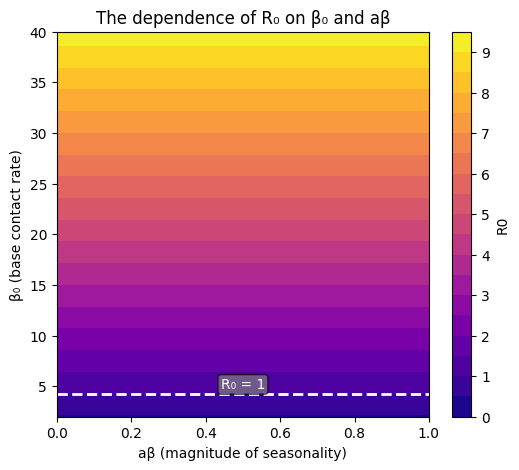

In [ ]:
# sự phụ thuộc của R₀ vào β0 và aβ
beta0_vals = np.linspace(2, 40, 20) # thay đổi dải giá trị cho beta0, bắt đầu từ 2 để quan sát R0 < 1
a_beta_vals = np.linspace(0, 1, 20)
R0_grid = np.zeros((len(beta0_vals), len(a_beta_vals)))

for i, b in enumerate(beta0_vals):
    for j, a in enumerate(a_beta_vals):
        R0_grid[i,j] = (b * sigma) / ((sigma + mu)*(gamma + mu)) # tính R0 cho mỗi cặp (beta0, a_beta)

plt.figure(figsize=(6,5))
plt.contourf(a_beta_vals, beta0_vals, R0_grid, levels=20, cmap='plasma')
plt.colorbar(label='R0')
plt.xlabel('aβ (magnitude of seasonality)')
plt.ylabel('β₀ (base contact rate)')
plt.title('The dependence of R₀ on β₀ and aβ')

# thêm đường R0=1 để dễ dàng nhận biết ngưỡng
plt.contour(a_beta_vals, beta0_vals, R0_grid, levels=[1], colors='white', linestyles='dashed', linewidths=2)
plt.annotate('R₀ = 1', xy=(0.5, 4.5), color='white', fontsize=10, ha='center', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', fc='gray', alpha=0.7))

plt.show()

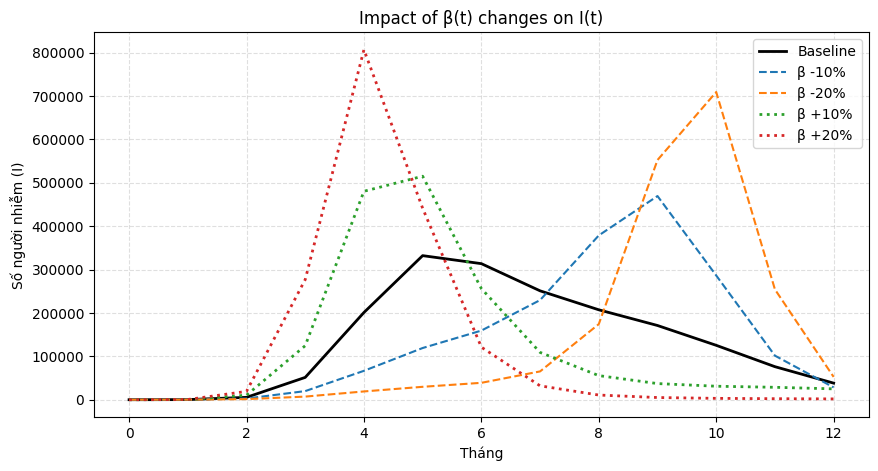

In [ ]:
# lấy tham số từ kết quả tối ưu (res.x)
beta0_fit, a_beta_fit, phi_fit = res.x

# scenario
def run_scenario(beta_scale):

    def ode_scaled(y, t_local):
        S, E, I, R = y

        current_beta0 = beta0_fit * beta_scale

        beta = beta0_fit * beta_scale * (1 + a_beta_fit * np.sin(2 * np.pi * t_local / 12 + phi_fit))

        # hệ phương trình SEIR
        dS = Lambda - beta * S * I / N - mu * S
        dE = beta * S * I / N - (sigma + mu) * E
        dI = sigma * E - (gamma + mu) * I
        dR = gamma * I - mu * R
        return [dS, dE, dI, dR]

    # giải hệ phương trình
    sol = odeint(ode_scaled, y0, t_data)

    return sol[:, 2]

# chạy mô phỏng các kịch bản
sol_baseline = odeint(seir_ode, y0, t_data, args=(res.x,))
I_model = sol_baseline[:, 2]

# tính các kịch bản thay đổi beta
I_minus20 = run_scenario(0.8) # giảm 20%
I_minus10 = run_scenario(0.9) # giảm 10%
I_plus10  = run_scenario(1.1) # tăng 10%
I_plus20  = run_scenario(1.2) # tăng 20%

plt.figure(figsize=(10, 5))

plt.plot(t_data, I_model, 'k-', lw=2, label='Baseline')
plt.plot(t_data, I_minus10, '--', color='tab:blue', label='β -10%')
plt.plot(t_data, I_minus20, '--', color='tab:orange', label='β -20%')
plt.plot(t_data, I_plus10, ':', color='tab:green', lw=2, label='β +10%')
plt.plot(t_data, I_plus20, ':', color='tab:red', lw=2, label='β +20%')
plt.title("Impact of β(t) changes on I(t)")
plt.xlabel("Tháng")
plt.ylabel("Số người nhiễm (I)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

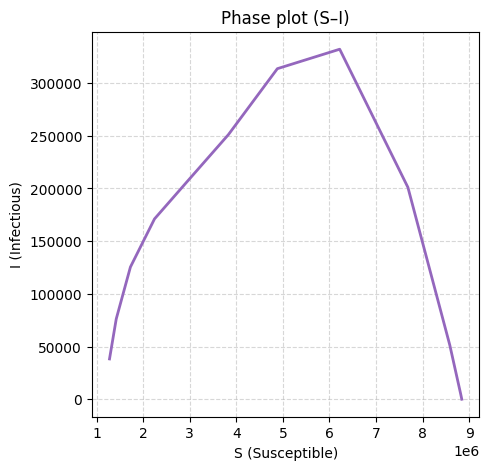

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(S, I_model, color='tab:purple', lw=2)
plt.xlabel("S (Susceptible)")
plt.ylabel("I (Infectious)")
plt.title("Phase plot (S–I)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

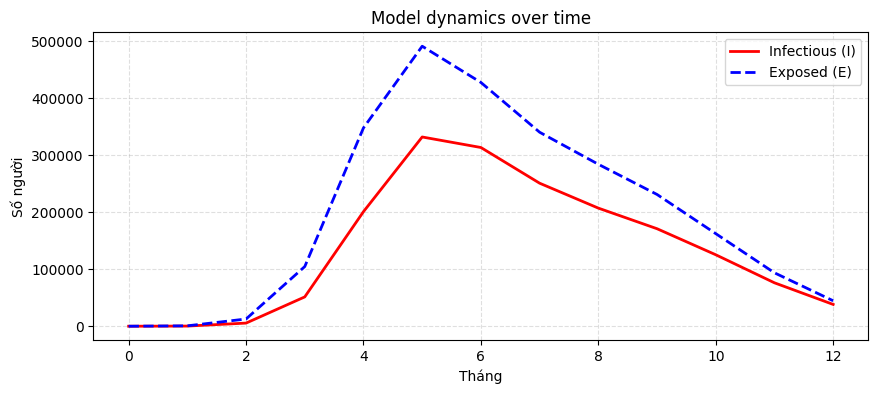

In [ ]:
# vẽ chu kỳ Infectious (I) và Exposed (E)
sol_full = odeint(seir_ode, y0, t_data, args=(res.x,))
S_model, E_model, I_model, R_model = sol_full.T

plt.figure(figsize=(10,4))
plt.plot(t_data, I_model, 'r-', lw=2, label='Infectious (I)')
plt.plot(t_data, E_model, 'b--', lw=2, label='Exposed (E)')
plt.title("Model dynamics over time")
plt.xlabel("Tháng")
plt.ylabel("Số người")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()